<a href="https://colab.research.google.com/github/OptimizationExpert/Pyomo/blob/main/Comparison_Distance_Exceed_of_CVRP_CP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Developed by Alireza Soroudi
alireza.soroudi@gmail.com

Linkedin News letter : https://www.linkedin.com/newsletters/optimization-in-open-source-6874020019009859585/

Git hub: https://github.com/OptimizationExpert/Pyomo

In [ ]:
import pandas as pd
!pip install ortools
from ortools.sat.python import cp_model
import matplotlib.pyplot as plt # Data visualization
import random
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 23.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 w

{1: (0.5, 0.5, 0),
 2: (0.3283313953469412, 0.010869763507873054, 16),
 3: (0.3984405779162933, 0.09553777940548025, 7),
 4: (0.8258577506203257, 0.7753229997566337, 9),
 5: (0.2275005272653564, 0.3774621339526346, 6),
 6: (0.20845753536745715, 0.8009436052903638, 9),
 7: (0.380837810951411, 0.4102709568702033, 5),
 8: (0.3517987926739158, 0.14060585212748533, 20),
 9: (0.23711619776419934, 0.3660625119928893, 20),
 10: (0.2641727006506648, 0.1100815332217917, 20),
 11: (0.6089805390762113, 0.7413913132405904, 16),
 12: (0.5629058330421507, 0.05890742966245743, 6),
 13: (0.07359694436849618, 0.12102683353521271, 11),
 14: (0.027104844570973508, 0.7808287533880613, 18),
 15: (0.614814121481449, 0.8161141721744173, 20),
 16: (0.13974327611657067, 0.12223725450850798, 1),
 17: (0.7723394331632762, 0.9658085188908329, 7),
 18: (0.07130124394476167, 0.1420355669565847, 13),
 19: (0.4310527346788221, 0.7267564934149399, 18),
 20: (0.10796189153564062, 0.49223443524173616, 16),
 21: (0.643095

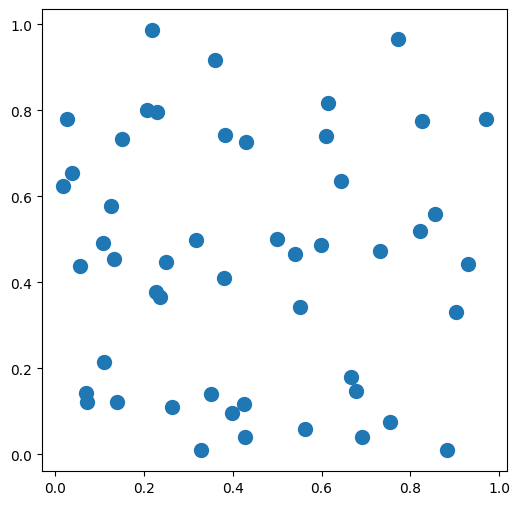

In [ ]:
n = 50
depot = 1
nodes = [i for i in range(1,1+n)]
data = {}
for n in nodes:
  data[n]=(random.random(),random.random(), random.randint(1,20))
data[depot]=(0.5, 0.5,0)
cars = range(4)
plt.figure(figsize=(6,6))
X= [data[n][0] for n in nodes]
Y= [data[n][1] for n in nodes]
plt.scatter(X,Y,s=100)
data

In [ ]:
def distance(n:int,m:int,data:dict)-> int:
  x1,y1 = data[n][0],data[n][1]
  x2,y2 = data[m][0],data[m][1]
  return int(100*np.sqrt( (x1-x2)**2+(y1-y2)**2))

distance(1,2,data)
print(nodes)

check = sum(data[n][2] for n in nodes)
print(check)
cap = {0:150, 1:190, 2:130, 3:100}
KOLORS = ['r','k','b','g']

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
553


# Min Total Exceed

Capacity  0 150
Capacity  1 190
Capacity  2 130
Capacity  3 100
Min of objective function: 334.0

Distance  0 229
Distance  1 308
Distance  2 239
Distance  3 270


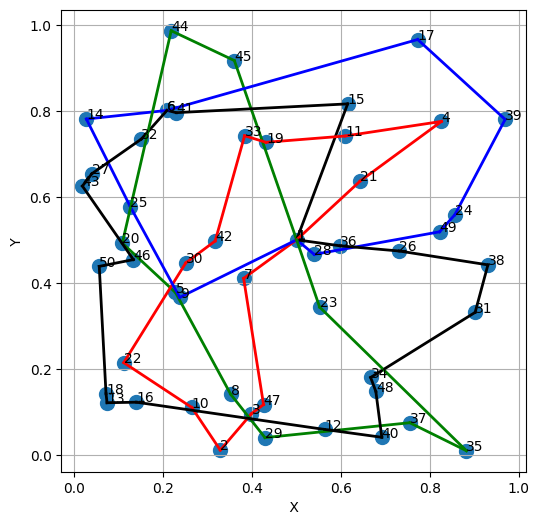

In [ ]:
def main() -> None:
    # Creates the model.
    threshhold = 178
    model = cp_model.CpModel()
    x={(i,j,c):model.NewBoolVar(f"flow_{i}_{j}_{c}") for i in nodes
       for j in nodes for c in cars if i!=j}
    assign = {(i,c): model.NewBoolVar(f"assign_{i}_{c}") for i in nodes for c in cars}
    used_car = {c: model.NewBoolVar(f"used_{c}") for c in cars}
    exceed_car = {c: model.NewBoolVar(f"exceed_{c}") for c in cars}
    exceed_car_dist = {c: model.NewIntVar(0,200,f"exceed_dist_{c}") for c in cars}
    for i in nodes:
      expressions = [assign[i,c] for c in cars]
      model.AddAtLeastOne(expressions)
    for (i,c),v in assign.items():
      model.Add(v<=used_car[c])
    for c in cars:
      model.Add(assign[depot,c]==used_car[c])
      arcs= [ (i,j,v) for (i,j,cc),v in x.items() if cc == c] + [(i,i,assign[i,c].Not()) for i in nodes]
      model.AddCircuit(arcs)
      expressions = [v*data[i][2] for (i,cc),v in assign.items() if c ==cc]
      model.Add(sum(expressions) <= cap[c])
      print('Capacity ', c,cap[c])
    for cc in cars:
        expressions_c = [distance(i,j,data)* v for (i,j,c),v in x.items() if c==cc]
        model.Add(sum(expressions_c) <= threshhold + exceed_car_dist[cc])

    #expressions_of = [distance(i,j,data)* v for (i,j,c),v in x.items() ]
    expressions_of = [ v for c,v in exceed_car_dist.items() ]
    model.minimize(sum(expressions_of))

    # Creates a solver and solves the model.
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 90
    status = solver.solve(model)

    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        print(f"Min of objective function: {solver.objective_value}\n")
        plt.figure(figsize=(6,6))
        X= [data[n][0] for n in nodes]
        Y= [data[n][1] for n in nodes]
        plt.scatter(X,Y,s=100)

        for (i,j,c),v in x.items():
          if solver.value(v)>0:
              x1,y1 = data[i][0],data[i][1]
              x2,y2 = data[j][0],data[j][1]
              plt.plot([x1,x2],[y1,y2], lw=2, c=KOLORS[c])
              plt.text(x1,y1,s=str(i))

        for cc in cars:
           expressions_c = [distance(i,j,data)* solver.value(v) for (i,j,c),v in x.items() if c==cc]
           print('Distance ', cc, sum(expressions_c))


        plt.xlabel(' X ')
        plt.ylabel(' Y ')
        plt.grid()

    else:
        print("No solution found.")

if __name__ == "__main__":
    main()

# Min Total Distance

Capacity  0 150
Capacity  1 190
Capacity  2 130
Capacity  3 100
Min of objective function: 1003.0

Distance  0 272
Distance  1 326
Distance  2 212
Distance  3 193


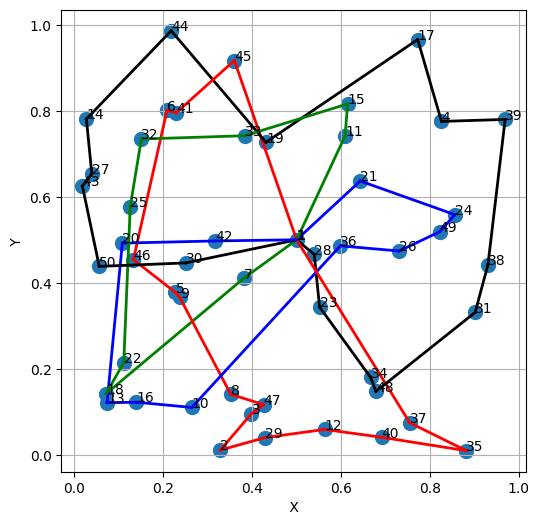

In [ ]:
def main() -> None:
    # Creates the model.
    threshhold = 178
    model = cp_model.CpModel()
    x={(i,j,c):model.NewBoolVar(f"flow_{i}_{j}_{c}") for i in nodes
       for j in nodes for c in cars if i!=j}
    assign = {(i,c): model.NewBoolVar(f"assign_{i}_{c}") for i in nodes for c in cars}
    used_car = {c: model.NewBoolVar(f"used_{c}") for c in cars}
    exceed_car = {c: model.NewBoolVar(f"exceed_{c}") for c in cars}
    exceed_car_dist = {c: model.NewIntVar(0,200,f"exceed_dist_{c}") for c in cars}
    for i in nodes:
      expressions = [assign[i,c] for c in cars]
      model.AddAtLeastOne(expressions)
    for (i,c),v in assign.items():
      model.Add(v<=used_car[c])
    for c in cars:
      model.Add(assign[depot,c]==used_car[c])
      arcs= [ (i,j,v) for (i,j,cc),v in x.items() if cc == c] + [(i,i,assign[i,c].Not()) for i in nodes]
      model.AddCircuit(arcs)
      expressions = [v*data[i][2] for (i,cc),v in assign.items() if c ==cc]
      model.Add(sum(expressions) <= cap[c])
      print('Capacity ', c,cap[c])
    for cc in cars:
        expressions_c = [distance(i,j,data)* v for (i,j,c),v in x.items() if c==cc]
        model.Add(sum(expressions_c) <= threshhold + exceed_car_dist[cc])

    expressions_of = [distance(i,j,data)* v for (i,j,c),v in x.items() ]
    #expressions_of = [ v for c,v in exceed_car_dist.items() ]
    model.minimize(sum(expressions_of))

    # Creates a solver and solves the model.
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 90
    status = solver.solve(model)

    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        print(f"Min of objective function: {solver.objective_value}\n")
        plt.figure(figsize=(6,6))
        X= [data[n][0] for n in nodes]
        Y= [data[n][1] for n in nodes]
        plt.scatter(X,Y,s=100)

        for (i,j,c),v in x.items():
          if solver.value(v)>0:
              x1,y1 = data[i][0],data[i][1]
              x2,y2 = data[j][0],data[j][1]
              plt.plot([x1,x2],[y1,y2], lw=2, c=KOLORS[c])
              plt.text(x1,y1,s=str(i))

        for cc in cars:
           expressions_c = [distance(i,j,data)* solver.value(v) for (i,j,c),v in x.items() if c==cc]
           print('Distance ', cc, sum(expressions_c))


        plt.xlabel(' X ')
        plt.ylabel(' Y ')
        plt.grid()

    else:
        print("No solution found.")

if __name__ == "__main__":
    main()

# Max travel

Capacity  0 150
Capacity  1 190
Capacity  2 130
Capacity  3 100
Min of objective function: 297.0

Distance  0 297
Distance  1 289
Distance  2 297
Distance  3 297


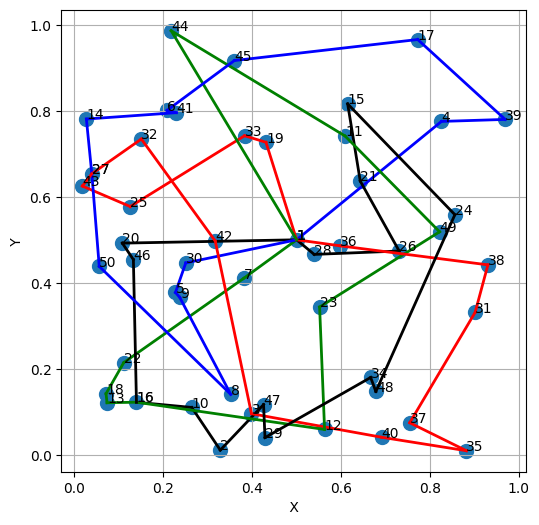

In [ ]:
def main() -> None:
    # Creates the model.
    threshhold = 178
    model = cp_model.CpModel()
    x={(i,j,c):model.NewBoolVar(f"flow_{i}_{j}_{c}") for i in nodes
       for j in nodes for c in cars if i!=j}
    assign = {(i,c): model.NewBoolVar(f"assign_{i}_{c}") for i in nodes for c in cars}
    used_car = {c: model.NewBoolVar(f"used_{c}") for c in cars}
    exceed_car = {c: model.NewBoolVar(f"exceed_{c}") for c in cars}
    exceed_car_dist = {c: model.NewIntVar(0,200,f"exceed_dist_{c}") for c in cars}
    of = model.NewIntVar(0,1000,f"of")
    for i in nodes:
      expressions = [assign[i,c] for c in cars]
      model.AddAtLeastOne(expressions)
    for (i,c),v in assign.items():
      model.Add(v<=used_car[c])
    for c in cars:
      model.Add(assign[depot,c]==used_car[c])
      arcs= [ (i,j,v) for (i,j,cc),v in x.items() if cc == c] + [(i,i,assign[i,c].Not()) for i in nodes]
      model.AddCircuit(arcs)
      expressions = [v*data[i][2] for (i,cc),v in assign.items() if c ==cc]
      model.Add(sum(expressions) <= cap[c])
      print('Capacity ', c,cap[c])
    for cc in cars:
        expressions_c = [distance(i,j,data)* v for (i,j,c),v in x.items() if c==cc]
        model.Add(sum(expressions_c) <=of)

    model.Minimize(of)
    #expressions_of = [ v for c,v in exceed_car_dist.items() ]

    # Creates a solver and solves the model.
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 90
    status = solver.solve(model)

    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        print(f"Min of objective function: {solver.objective_value}\n")
        plt.figure(figsize=(6,6))
        X= [data[n][0] for n in nodes]
        Y= [data[n][1] for n in nodes]
        plt.scatter(X,Y,s=100)

        for (i,j,c),v in x.items():
          if solver.value(v)>0:
              x1,y1 = data[i][0],data[i][1]
              x2,y2 = data[j][0],data[j][1]
              plt.plot([x1,x2],[y1,y2], lw=2, c=KOLORS[c])
              plt.text(x1,y1,s=str(i))

        for cc in cars:
           expressions_c = [distance(i,j,data)* solver.value(v) for (i,j,c),v in x.items() if c==cc]
           print('Distance ', cc, sum(expressions_c))


        plt.xlabel(' X ')
        plt.ylabel(' Y ')
        plt.grid()

    else:
        print("No solution found.")

if __name__ == "__main__":
    main()

# Balance

Capacity  0 150
Capacity  1 190
Capacity  2 130
Capacity  3 100
Min of objective function: 422.0

Distance  0 422
Distance  1 422
Distance  2 422
Distance  3 422


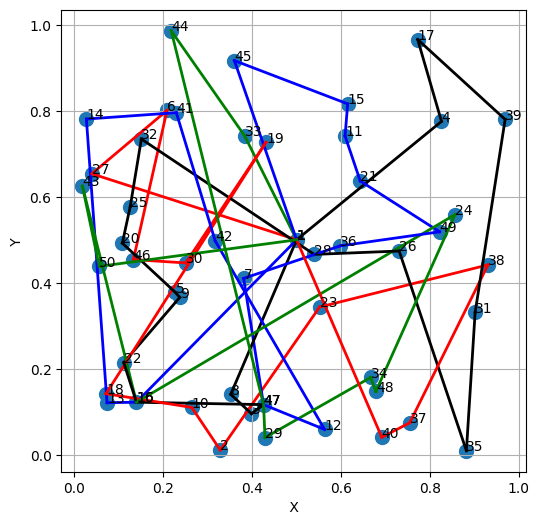

In [ ]:
def main() -> None:
    # Creates the model.
    threshhold = 178
    model = cp_model.CpModel()
    x={(i,j,c):model.NewBoolVar(f"flow_{i}_{j}_{c}") for i in nodes
       for j in nodes for c in cars if i!=j}
    assign = {(i,c): model.NewBoolVar(f"assign_{i}_{c}") for i in nodes for c in cars}
    used_car = {c: model.NewBoolVar(f"used_{c}") for c in cars}
    exceed_car = {c: model.NewBoolVar(f"exceed_{c}") for c in cars}
    exceed_car_dist = {c: model.NewIntVar(0,200,f"exceed_dist_{c}") for c in cars}
    of_max= model.NewIntVar(0,1000,f"ofmax")
    of_min= model.NewIntVar(0,1000,f"ofmin")

    for i in nodes:
      expressions = [assign[i,c] for c in cars]
      model.AddAtLeastOne(expressions)
    for (i,c),v in assign.items():
      model.Add(v<=used_car[c])
    for c in cars:
      model.Add(assign[depot,c]==used_car[c])
      arcs= [ (i,j,v) for (i,j,cc),v in x.items() if cc == c] + [(i,i,assign[i,c].Not()) for i in nodes]
      model.AddCircuit(arcs)
      expressions = [v*data[i][2] for (i,cc),v in assign.items() if c ==cc]
      model.Add(sum(expressions) <= cap[c])
      print('Capacity ', c,cap[c])
    for cc in cars:
        expressions_c = [distance(i,j,data)* v for (i,j,c),v in x.items() if c==cc]
        model.Add(sum(expressions_c) <=of_max)
        model.Add(sum(expressions_c) >=of_min)


    model.Minimize(2*of_max-of_min)
    #expressions_of = [ v for c,v in exceed_car_dist.items() ]

    # Creates a solver and solves the model.
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 90
    status = solver.solve(model)

    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        print(f"Min of objective function: {solver.objective_value}\n")
        plt.figure(figsize=(6,6))
        X= [data[n][0] for n in nodes]
        Y= [data[n][1] for n in nodes]
        plt.scatter(X,Y,s=100)

        for (i,j,c),v in x.items():
          if solver.value(v)>0:
              x1,y1 = data[i][0],data[i][1]
              x2,y2 = data[j][0],data[j][1]
              plt.plot([x1,x2],[y1,y2], lw=2, c=KOLORS[c])
              plt.text(x1,y1,s=str(i))

        for cc in cars:
           expressions_c = [distance(i,j,data)* solver.value(v) for (i,j,c),v in x.items() if c==cc]
           print('Distance ', cc, sum(expressions_c))


        plt.xlabel(' X ')
        plt.ylabel(' Y ')
        plt.grid()

    else:
        print("No solution found.")

if __name__ == "__main__":
    main()